In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random

In [2]:
# Configurações
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ============================================
# 1. PRÉ-PROCESSAMENTO DOS DADOS
# ============================================

class SequenceProcessor:
    """Processa as sequências comportamentais do CSV"""

    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
        self.vocab = self._build_vocab()
        self.species_names = self.df.columns.tolist()

    def _build_vocab(self):
        """Constrói um vocabulário de todos os comportamentos"""
        all_behaviors = set()
        for col in self.df.columns:
            sequences = self.df[col].dropna().astype(str)
            for seq in sequences:
                all_behaviors.update(seq.split())

        vocab = {beh: idx + 1 for idx, beh in enumerate(sorted(all_behaviors))}
        vocab['<PAD>'] = 0  # Padding token
        return vocab

    def encode_sequence(self, sequence_str, max_length=100):
        """Converte string de comportamentos em tensor de índices"""
        behaviors = sequence_str.split()
        indices = [self.vocab.get(b, 0) for b in behaviors]

        # Padding ou truncamento
        if len(indices) < max_length:
            indices = indices + [0] * (max_length - len(indices))
        else:
            indices = indices[:max_length]

        return torch.tensor(indices, dtype=torch.long)

    def get_all_sequences(self, max_length=100):
        """Retorna todas as sequências codificadas"""
        sequences = []
        species_labels = []

        for col in self.df.columns:
            for seq in self.df[col].dropna().astype(str):
                sequences.append(self.encode_sequence(seq, max_length))
                species_labels.append(col)

        return sequences, species_labels




In [10]:
# ============================================
# 2. DATASET PARA PARES DE SEQUÊNCIAS
# ============================================

class SiameseSequenceDataset(Dataset):
    """Dataset que gera pares de sequências para treinamento"""

    def __init__(self, sequences, labels, num_pairs=1000):
        self.sequences = sequences
        self.labels = labels
        self.num_pairs = num_pairs

        # Agrupa por espécie
        self.species_indices = {}
        for idx, label in enumerate(labels):
            if label not in self.species_indices:
                self.species_indices[label] = []
            self.species_indices[label].append(idx)

        self.pairs = self._generate_pairs()

    def _generate_pairs(self):
        """Gera pares positivos (mesma espécie) e negativos (espécies diferentes)"""
        pairs = []
        species_list = list(self.species_indices.keys())

        for _ in range(self.num_pairs):
            if random.random() < 0.5:  # Par positivo (mesma espécie)
                species = random.choice(species_list)
                indices = self.species_indices[species]
                if len(indices) >= 2:
                    idx1, idx2 = random.sample(indices, 2)
                    pairs.append((idx1, idx2, 1))  # Label 1 = similar
            else:  # Par negativo (espécies diferentes)
                species1, species2 = random.sample(species_list, 2)
                idx1 = random.choice(self.species_indices[species1])
                idx2 = random.choice(self.species_indices[species2])
                pairs.append((idx1, idx2, 0))  # Label 0 = dissimilar

        return pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        idx1, idx2, label = self.pairs[idx]
        return self.sequences[idx1], self.sequences[idx2], torch.tensor(label, dtype=torch.float32)




In [11]:
# ============================================
# 3. ARQUITETURA DA REDE SIAMESA
# ============================================

class SequenceEncoder(nn.Module):
    """Encoder de sequências com Embedding + LSTM"""

    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=2):
        super(SequenceEncoder, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

    def forward(self, x):
        # x: (batch_size, seq_length)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)

        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Usa a concatenação dos últimos estados hidden de ambas as direções
        hidden_fwd = hidden[-2]  # Última camada forward
        hidden_bwd = hidden[-1]  # Última camada backward
        encoding = torch.cat([hidden_fwd, hidden_bwd], dim=1)

        return encoding


class SiameseNetwork(nn.Module):
    """Rede Siamesa completa"""

    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super(SiameseNetwork, self).__init__()

        self.encoder = SequenceEncoder(vocab_size, embedding_dim, hidden_dim)

    def forward(self, seq1, seq2):
        # Codifica ambas as sequências
        encoding1 = self.encoder(seq1)
        encoding2 = self.encoder(seq2)

        return encoding1, encoding2



In [12]:
# ============================================
# 4. FUNÇÃO DE PERDA
# ============================================

class ContrastiveLoss(nn.Module):
    """Contrastive Loss para redes siamesas"""

    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, encoding1, encoding2, label):
        # Distância euclidiana
        distance = torch.nn.functional.pairwise_distance(encoding1, encoding2)

        # Loss: para pares similares (label=1), minimiza distância
        #       para pares dissimilares (label=0), maximiza distância (até margin)
        loss = (label * distance.pow(2) +
                (1 - label) * torch.clamp(self.margin - distance, min=0.0).pow(2))

        return loss.mean()



In [14]:
# ============================================
# 5. TREINAMENTO
# ============================================

def train_model(model, train_loader, criterion, optimizer, num_epochs=20, device='cpu'):
    """Treina a rede siamesa"""

    model = model.to(device)
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0

        for seq1, seq2, labels in train_loader:
            seq1, seq2, labels = seq1.to(device), seq2.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            encoding1, encoding2 = model(seq1, seq2)
            loss = criterion(encoding1, encoding2, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    return model


Processando dados...
Vocabulário: 22 comportamentos únicos
Total de sequências: 11096
Espécies: 13

Iniciando treinamento...
Epoch [1/20], Loss: 1.0779
Epoch [2/20], Loss: 1.0117
Epoch [3/20], Loss: 1.0180
Epoch [4/20], Loss: 1.0155
Epoch [5/20], Loss: 1.0136
Epoch [6/20], Loss: 1.0056
Epoch [7/20], Loss: 1.0081
Epoch [8/20], Loss: 1.0051
Epoch [9/20], Loss: 1.0010
Epoch [10/20], Loss: 1.0040
Epoch [11/20], Loss: 0.9999
Epoch [12/20], Loss: 0.9984
Epoch [13/20], Loss: 0.9954
Epoch [14/20], Loss: 0.9979
Epoch [15/20], Loss: 1.0057
Epoch [16/20], Loss: 0.9921
Epoch [17/20], Loss: 0.9961
Epoch [18/20], Loss: 0.9993
Epoch [19/20], Loss: 0.9982
Epoch [20/20], Loss: 0.9947

Gerando visualização dos embeddings...


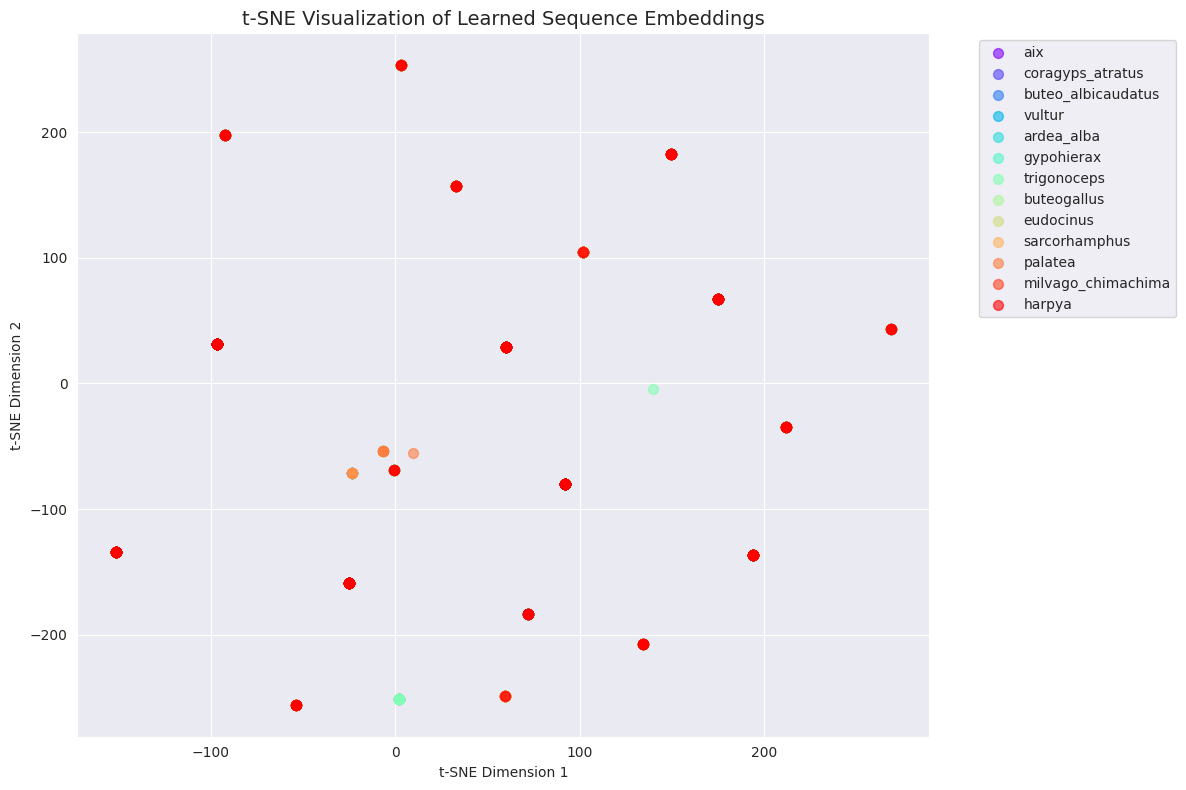


Treinamento concluído!
Embeddings salvos em 'siamese_embeddings.png'
Modelo salvo em 'siamese_model.pth'


In [15]:

# ============================================
# 6. VISUALIZAÇÃO DOS EMBEDDINGS
# ============================================

def visualize_embeddings(model, sequences, species_labels, device='cpu'):
    """Visualiza os embeddings aprendidos usando t-SNE"""

    model.eval()
    model = model.to(device)

    # Extrai embeddings de todas as sequências
    embeddings = []
    with torch.no_grad():
        for seq in sequences:
            seq = seq.unsqueeze(0).to(device)
            encoding = model.encoder(seq)
            embeddings.append(encoding.cpu().numpy())

    embeddings = np.vstack(embeddings)

    # t-SNE para redução de dimensionalidade
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 8))
    unique_species = list(set(species_labels))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_species)))

    for species, color in zip(unique_species, colors):
        indices = [i for i, label in enumerate(species_labels) if label == species]
        plt.scatter(
            embeddings_2d[indices, 0],
            embeddings_2d[indices, 1],
            c=[color],
            label=species,
            alpha=0.6,
            s=50
        )

    plt.title('t-SNE Visualization of Learned Sequence Embeddings', fontsize=14)
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('siamese_embeddings.png', dpi=300, bbox_inches='tight')
    plt.show()

    return embeddings_2d


# ============================================
# 7. EXEMPLO DE USO
# ============================================

def main():
    # Configurações
    CSV_PATH = 'sequencias/sequencias_todas.csv'  # Substitua pelo caminho do seu CSV
    MAX_SEQ_LENGTH = 100
    EMBEDDING_DIM = 64
    HIDDEN_DIM = 128
    NUM_PAIRS = 2000
    BATCH_SIZE = 32
    NUM_EPOCHS = 20
    LEARNING_RATE = 0.001

    # 1. Processa os dados
    print("Processando dados...")
    processor = SequenceProcessor(CSV_PATH)
    sequences, species_labels = processor.get_all_sequences(MAX_SEQ_LENGTH)
    vocab_size = len(processor.vocab)

    print(f"Vocabulário: {vocab_size} comportamentos únicos")
    print(f"Total de sequências: {len(sequences)}")
    print(f"Espécies: {len(set(species_labels))}")

    # 2. Cria dataset e dataloader
    dataset = SiameseSequenceDataset(sequences, species_labels, NUM_PAIRS)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 3. Inicializa modelo
    model = SiameseNetwork(vocab_size, EMBEDDING_DIM, HIDDEN_DIM)
    criterion = ContrastiveLoss(margin=2.0)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. Treina
    print("\nIniciando treinamento...")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = train_model(model, dataloader, criterion, optimizer, NUM_EPOCHS, device)

    # 5. Visualiza embeddings
    print("\nGerando visualização dos embeddings...")
    embeddings_2d = visualize_embeddings(model, sequences, species_labels, device)

    print("\nTreinamento concluído!")
    print("Embeddings salvos em 'siamese_embeddings.png'")

    # Salva o modelo
    torch.save(model.state_dict(), 'siamese_model.pth')
    print("Modelo salvo em 'siamese_model.pth'")


if __name__ == "__main__":
    main()
